# Load SP500 stock data using Yahoo Finance

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import datetime
import yfinance as yf

In [2]:
# Optional: interactive DataFrame tables in Jupyter (requires: pip install itables)
# Old API `init_itables(bootstrap_mode=True)` was removed; use `init_notebook_mode`.
# connected=True loads DataTables from CDN (similar idea to bootstrap CDN).
from itables import init_notebook_mode

init_notebook_mode(all_interactive=True, connected=True)

In [3]:
from dotenv import load_dotenv
load_dotenv()

from pairs_eda import fetch_sp500_constituents_table, default_gemini_backend, ExaRunMode

exa_backend = default_gemini_backend()
sp500 = fetch_sp500_constituents_table(
    on_failure="exa",
    exa_backend=exa_backend,
    exa_mode=ExaRunMode.LIVE,
    verbose=True,
)

sp500_list = sp500["Symbol"].tolist()
print(f"{len(sp500_list)} symbols fetched")

[pairs_eda] Fetching https://en.wikipedia.org/wiki/List_of_S%26P_500_companies …
[pairs_eda] Extracting tables …
[pairs_eda] Done (503 rows from https://en.wikipedia.org/wiki/List_of_S%26P_500_companies).
503 symbols fetched


In [4]:
# ── Time Configuration ──
# WFA uses rolling windows, so no strict per-ticker date filter is needed.
# Tickers with shorter history naturally join later rebalance windows.
# Pair-level overlap is enforced by find_candidate_pairs(min_overlap_years).

DOWNLOAD_START = "1990-01-01"          # go as far back as yfinance allows

PHASE2A_DAYS = 730
PHASE2A_INTERVAL = "1h"
PHASE2B_DAYS = 60
PHASE2B_INTERVAL = "5m"

end_time = datetime.datetime.today()
p2b_end   = end_time - pd.DateOffset(days=1)                        # yesterday
p2b_start = p2b_end  - pd.DateOffset(days=PHASE2B_DAYS - 1)         # 60 days inclusive
p2a_end   = p2b_start - pd.DateOffset(days=1)                       # day before Phase 2b
p2a_start = p2a_end  - pd.DateOffset(days=PHASE2A_DAYS - 1)         # 730 days inclusive
p1_end    = p2a_start - pd.DateOffset(days=1)                       # day before Phase 2a

print(f"Phase 1  download: {DOWNLOAD_START} → {p1_end.date()}")
print(f"Phase 2a window:   {p2a_start.date()} → {p2a_end.date()} ({PHASE2A_DAYS}d, {PHASE2A_INTERVAL})")
print(f"Phase 2b window:   {p2b_start.date()} → {p2b_end.date()} ({PHASE2B_DAYS}d, {PHASE2B_INTERVAL})")


Phase 1  download: 1990-01-01 → 2024-01-26
Phase 2a window:   2024-01-27 → 2026-01-25 (730d, 1h)
Phase 2b window:   2026-01-26 → 2026-03-26 (60d, 5m)


In [5]:
from pairs_eda import download_with_retry

# ── Phase 1: Download daily OHLCV (maximum history) ──
# auto_adjust=False: preserves "Adj Close" column separately.
# Over 10-35 years, Adj Close differs significantly from Close
# (e.g. JPM adj/close ratio ≈ 0.32 at 1990 due to decades of splits/dividends).
# Pairs trading MUST use Adj Close so corporate actions don't create false spread signals.
sp500_daily_prices = download_with_retry(
    sp500_list,
    start=DOWNLOAD_START,
    end=p1_end,
    interval="1d",
    progress=True,
    threads=True,
    auto_adjust=False,
    max_retries=2,
    retry_delay=5.0,
)

# No per-ticker date filter — overlap is checked at the PAIR level
# by find_candidate_pairs(min_overlap_years, recent_years).
# This allows newer stocks (GOOGL, TSLA, META, etc.) to participate.

# ── Data availability summary ──
first_valid = pd.Series({col: sp500_daily_prices[col].first_valid_index() for col in sp500_daily_prices.columns})
print(f"\nPhase 1 data:")
print(f"  Tickers:       {sp500_daily_prices.shape[1]}")
print(f"  Trading days:  {sp500_daily_prices.shape[0]}")
print(f"  Earliest data: {first_valid.min().date()}")
print(f"  Median start:  {first_valid.median().date()}")
print(f"  p1_end:        {p1_end.date()}")


[pairs_eda] Downloading 503 tickers …


[********              17%                       ]  83 of 503 completed$SOLV: possibly delisted; no price data found  (1d 1990-01-01 -> 2024-01-26 03:44:09.437269) (Yahoo error = "Data doesn't exist for startDate = 631170000, endDate = 1706258649")
[**************        30%                       ]  150 of 503 completed$SNDK: possibly delisted; no price data found  (1d 1990-01-01 -> 2024-01-26 03:44:09.437269) (Yahoo error = "Data doesn't exist for startDate = 631170000, endDate = 1706258649")
[**********************62%*****                  ]  313 of 503 completed$Q: possibly delisted; no price data found  (1d 1990-01-01 -> 2024-01-26 03:44:09.437269) (Yahoo error = "Data doesn't exist for startDate = 631170000, endDate = 1706258649")
[**********************63%*****                  ]  315 of 503 completed$GEV: possibly delisted; no price data found  (1d 1990-01-01 -> 2024-01-26 03:44:09.437269) (Yahoo error = "Data doesn't exist for startDate = 631170000, endDate = 1706258649")
[****

[pairs_eda] Using 'Adj Close' — split/dividend adjustments detected.
[pairs_eda] Retry 1/2: 4 failed tickers → ['GEV', 'Q', 'SNDK', 'SOLV']


$SOLV: possibly delisted; no price data found  (1d 1990-01-01 -> 2024-01-26 03:44:09.437269) (Yahoo error = "Data doesn't exist for startDate = 631170000, endDate = 1706258649")
$SNDK: possibly delisted; no price data found  (1d 1990-01-01 -> 2024-01-26 03:44:09.437269) (Yahoo error = "Data doesn't exist for startDate = 631170000, endDate = 1706258649")
[                       0%                       ]$Q: possibly delisted; no price data found  (1d 1990-01-01 -> 2024-01-26 03:44:09.437269) (Yahoo error = "Data doesn't exist for startDate = 631170000, endDate = 1706258649")
[                       0%                       ]$GEV: possibly delisted; no price data found  (1d 1990-01-01 -> 2024-01-26 03:44:09.437269) (Yahoo error = "Data doesn't exist for startDate = 631170000, endDate = 1706258649")
[*********************100%***********************]  4 of 4 completed

4 Failed downloads:
['SOLV', 'SNDK', 'Q', 'GEV']: possibly delisted; no price data found  (1d 1990-01-01 -> 2024-01-26 03:

[pairs_eda] Retry 1: still no data.
[pairs_eda] Retry 2/2: 4 failed tickers → ['GEV', 'Q', 'SNDK', 'SOLV']


$SOLV: possibly delisted; no price data found  (1d 1990-01-01 -> 2024-01-26 03:44:09.437269) (Yahoo error = "Data doesn't exist for startDate = 631170000, endDate = 1706258649")
$SNDK: possibly delisted; no price data found  (1d 1990-01-01 -> 2024-01-26 03:44:09.437269) (Yahoo error = "Data doesn't exist for startDate = 631170000, endDate = 1706258649")
[                       0%                       ]$GEV: possibly delisted; no price data found  (1d 1990-01-01 -> 2024-01-26 03:44:09.437269) (Yahoo error = "Data doesn't exist for startDate = 631170000, endDate = 1706258649")
[                       0%                       ]$Q: possibly delisted; no price data found  (1d 1990-01-01 -> 2024-01-26 03:44:09.437269) (Yahoo error = "Data doesn't exist for startDate = 631170000, endDate = 1706258649")
[*********************100%***********************]  4 of 4 completed

4 Failed downloads:
['SOLV', 'SNDK', 'GEV', 'Q']: possibly delisted; no price data found  (1d 1990-01-01 -> 2024-01-26 03:

[pairs_eda] Retry 2: still no data.
[pairs_eda] Dropping 4 tickers after all retries: ['GEV', 'Q', 'SNDK', 'SOLV']

Phase 1 data:
  Tickers:       499
  Trading days:  8582
  Earliest data: 1990-01-02
  Median start:  1991-10-24
  p1_end:        2024-01-26


In [6]:
# ── Volatility Pre-Filter ─────────────────────────────────────────────────────
# MOVED INTO WFA: filter_volatile_tickers is now applied inside each
# Phase 1 training window (compute_robust_pair_scores) to avoid look-ahead bias.
# Configure via RollingPhase2Config(max_drop_quantile=0.90).
#
# Applying the filter here on the FULL history would use future crash data
# to exclude tickers from past windows — a subtle but real look-ahead bias.
print("Volatility filter: deferred to WFA (per-rebalance, no look-ahead bias)")

Volatility filter: deferred to WFA (per-rebalance, no look-ahead bias)


# Deriving highly correlated stock combinations for pair trading

## Phase 1 / 2a / 2b

| Phase | Purpose | Interval | Period |
|-------|---------|----------|--------|
| **Phase 1** | Correlation, cointegration, strategy optimization, regime detection | Daily (1d) | Max history → p1_end |
| **Phase 2a** | Reassurance across recent market events (volatility, rate changes) | 1-hour (1h) | 730 days (p2a_start → p2a_end) |
| **Phase 2b** | Execution-level validation (slippage, spread mechanics) | 5-minute (5m) | 60 days (p2b_start → p2b_end) |


In [7]:
# ── Phase Timeline ──
#
#   1990                       p1_end  p2a_start       p2a_end  p2b_start    p2b_end
#   |======== P1 (daily) ======|       |==== P2a (1h) ===|      |== P2b (5m) ==|
#   DOWNLOAD_START              ↑       730 days                  60 days       yesterday
#                     pair overlap checked here (≥5yr + 3yr recency)
#
# Three SEPARATE downloads:
#   P1  = daily Adj Close  (26+ years, 4 major regime crises)
#   P2a = 1h Adj Close    (2 years, recent event coverage)
#   P2b = 5m Adj Close    (60 days, execution mechanics)

print(f"Phase 1:  {DOWNLOAD_START} → {p1_end.date()}  (all available daily data)")
print(f"Phase 2a: {p2a_start.date()} → {p2a_end.date()}  ({(p2a_end - p2a_start).days + 1} calendar days, {PHASE2A_INTERVAL})")
print(f"Phase 2b: {p2b_start.date()} → {p2b_end.date()}  ({(p2b_end - p2b_start).days + 1} calendar days, {PHASE2B_INTERVAL})")


Phase 1:  1990-01-01 → 2024-01-26  (all available daily data)
Phase 2a: 2024-01-27 → 2026-01-25  (730 calendar days, 1h)
Phase 2b: 2026-01-26 → 2026-03-26  (60 calendar days, 5m)


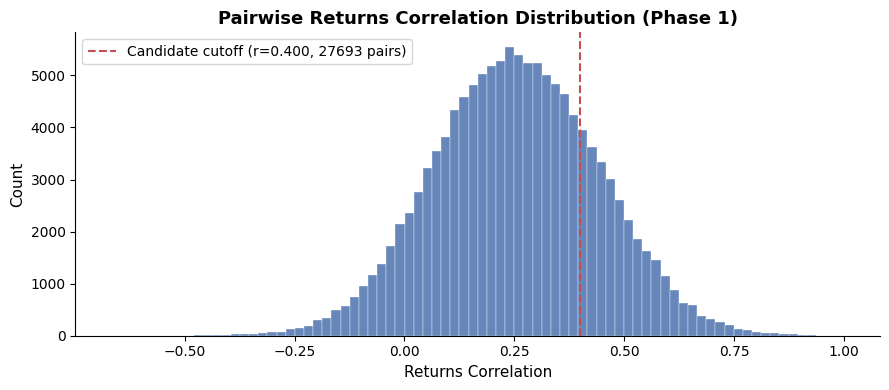

In [8]:
import matplotlib.pyplot as plt
from pairs_eda import compute_pairwise_return_correlations, plot_correlation_histogram

all_corr = compute_pairwise_return_correlations(sp500_daily_prices, end=p1_end)
fig, ax = plot_correlation_histogram(all_corr, cutoff=0.40)
plt.show()


In [9]:
from ipywidgets import interact, Output, widgets
from plotly import graph_objs as go
from IPython.display import display, clear_output
from pairs_eda import find_candidate_pairs

# Select candidate pairs: r in [0.40, 0.85], dual condition (full + 3yr recent).
# Hover over find_candidate_pairs for the full filtering logic.
pair_correlations = find_candidate_pairs(sp500_daily_prices, end=p1_end, min_correlation=0.40, max_correlation=0.85)
high_correlated_pairs = list(pair_correlations.keys())
print(f"{len(high_correlated_pairs)} candidate pairs")

# Dropdown: top 100 pairs by correlation, pick one to see dual-axis price chart.
top_pairs = list(pair_correlations.keys())[:100]

pair_dropdown = widgets.Dropdown(
    options=[(f"{a} / {b}  (r={pair_correlations[(a,b)]:.4f})", (a, b)) for a, b in top_pairs],
    description="Pair:",
)

plot_output = Output()
display(plot_output)

def update_graph(selected_pair):
    with plot_output:
        clear_output(wait=True)
        a, b = selected_pair
        pair_data = sp500_daily_prices[[a, b]].dropna()
        # Normalize: both start at 1.0 from their first overlapping date
        normalized = pair_data / pair_data.iloc[0]
        fig = go.Figure()
        fig.add_trace(go.Scatter(x=normalized.index, y=normalized[a], name=a))
        fig.add_trace(go.Scatter(x=normalized.index, y=normalized[b], name=b))
        fig.update_layout(
            yaxis=dict(title=dict(text="Price (normalized to 1.0)")),
            title=f"{a} vs {b} — Normalized Price (r={pair_correlations[(a,b)]:.4f})",
            xaxis_title="Date",
        )
        fig.show()

interact(update_graph, selected_pair=pair_dropdown);

15896 candidate pairs


Output()

interactive(children=(Dropdown(description='Pair:', options=(('CFG / USB  (r=0.8349)', ('CFG', 'USB')), ('BAC …

## Cointegration Test — The Real Pair Selection

Correlation is a **coarse pre-filter**.  Two stocks trending up together
will have high correlation, but the spread may never revert — which is
what pairs trading actually bets on.

**Cointegration** (Engle-Granger two-step) verifies that the spread is
stationary and mean-reverting:

```
high_correlated_pairs  (~4K–14K pairs)
       │
       ▼  find_cointegrated_pairs(significance=0.05)
           1. OLS:  log(A) = α + β·log(B) + ε
           2. ADF test on ε  →  p-value
           3. keep if p < 0.05
       │
stationary_pairs  (~200–500 pairs)
       │
       ▼  grid search optimization (only on these)
```

This reduces computation by **~30×** while keeping only pairs with
a statistically validated mean-reverting spread.


In [10]:
# [SUPERSEDED BY WFA] Cointegration filtering is now performed INSIDE each
# Phase 1 rebalance window by compute_robust_pair_scores → filter_cointegrated_cached.
# Running it here on the FULL history would be look-ahead bias.
#
# from pairs_eda import find_cointegrated_pairs
# stationary_pairs = find_cointegrated_pairs(
#     high_correlated_pairs,
#     sp500_daily_prices,
#     significance=0.05,
# )
# print(f"{len(stationary_pairs)} cointegrated pairs from {len(high_correlated_pairs)} candidates")
print("Cointegration filter: deferred to WFA (per-rebalance, no look-ahead bias)")


Cointegration filter: deferred to WFA (per-rebalance, no look-ahead bias)


# Pair Trading Backtesting (Functional)

### Functional Pipeline

Each step is an independent, testable function. Data flows explicitly through arguments and return values — no hidden state.

```
compute_zscore  →  compute_signals  →  summarize_signals  →  calculate_margin
                                                                     ↓
backtest_pair (chains all four)                              {margin, trade_log}
grid_search_pair (parameter sweep)
```

## Step-by-Step Demo: One Pair Backtest

Using the **top-ranked pair from ** as a worked example,
this section walks through each stage of the backtest pipeline.  
Run cells **in order** and inspect each intermediate result at every step.

---

### Pipeline Flow



---

### Parameters

| Parameter | Value | Meaning |
|---|---|---|
|  | 10 | z-score rolling window (trading days) |
|  | 2.0 | entry threshold — signal fires when \|z\| ≥ 2.0 |
|  | 3,000 | initial margin / collateral (USD) |
|  | 0.25 | margin ratio — 0.25 = **4× leverage** (buying power = margin ÷ 0.25) |

> **Bankruptcy threshold**: margin < $2 → cannot cover minimum commission ($1/leg)
> → simulation stops and  is recorded

In [11]:
# ── Imports ──────────────────────────────────────────────────────────────────
# run_pair_pipeline : runs all 4 steps in sequence; stores every intermediate in PairPipelineState
#   call .to_backtest_result() to extract compact dict {pair, window, zscore_threshold, margin}
# grid_search_pair  : runs run_pair_pipeline over the full parameter grid
import numpy as np
from pairs_eda.backtesting import (
    grid_search_pair,
    run_pair_pipeline,
)

In [12]:
from typing import cast

import pandas as pd

from pairs_eda.display import (
    print_margin_summary,
    print_signal_distribution,
    print_signal_groups,
    print_zscore_summary,
)

# ── 1. Choose the pair ────────────────────────────────────────────────────────
# Pick the top-ranked pair that survived the volatility filter and correlation filter.
# Using the first entry from high_correlated_pairs ensures the demo always runs
# on a pair that is actually present in sp500_daily_prices.
demo_pair = next(iter(high_correlated_pairs))
print(f"Demo pair: {demo_pair[0]} / {demo_pair[1]}")

# Drop NaN rows from each Adj Close series; keep only the date range covered by both tickers.
# → Removes dates where one ticker listed later or has missing data, aligning both indexes.
prices_a = sp500_daily_prices[demo_pair[0]].dropna()
prices_b = sp500_daily_prices[demo_pair[1]].dropna()
common_idx = prices_a.index.intersection(prices_b.index)
# cast: single-column DataFrame access returns Series|DataFrame to Pyright; narrow explicitly.
prices_a = cast(pd.Series, prices_a.loc[common_idx])
prices_b = cast(pd.Series, prices_b.loc[common_idx])

# ── 2. Parameters ─────────────────────────────────────────────────────────────
WINDOW       = 10    # z-score rolling window (trading days)
THRESHOLD    = 2.0   # signal threshold  — entry when |z| >= 2.0
MARGIN_INIT  = 3000  # initial margin (USD)
MARGIN_RATIO = 0.25  # margin ratio  → buying power = $3000 / 0.25 = $12,000
STOP_LOSS    = 0.05  # exit early if unrealized loss exceeds 5% of buying power

# ── 3. Run the pipeline ───────────────────────────────────────────────────────
# run_pair_pipeline executes all 4 steps in order and stores every intermediate artifact.
#
#   compute_zscore -> compute_signals -> summarize_signals -> calculate_margin
#
# fractional=True  : equal dollar allocation per leg (fractional shares allowed)
# fractional=False : integer shares via math.floor (closer to a real brokerage account)
pipeline_state = run_pair_pipeline(
    prices_a=prices_a,
    prices_b=prices_b,
    window=WINDOW,
    zscore_threshold=THRESHOLD,
    margin_init=MARGIN_INIT,
    margin_ratio=MARGIN_RATIO,
    pair=demo_pair,
    fractional=True,
    stop_loss_pct=STOP_LOSS,
)

# ── 4. Unpack intermediates ───────────────────────────────────────────────────
# pair_stats    : date-indexed DataFrame — ratio / ma / msd / zscore / signal
#                 inspect to verify how z-score and signal were computed for each date
# signal_summary: one-row-per-period DataFrame — date ranges, prices, pnl, commission, ...
#                 pnl/commission columns are filled only for active trades (signal != 0)
pair_stats     = pipeline_state.pair_stats
signal_summary = pipeline_state.signal_summary

Demo pair: CFG / USB


---

### Step 1 — Z-Score: How Far Is the Spread From Normal?

Inspect the `pair_stats` DataFrame to see how each column is derived.

| Column | Meaning |
|---|---|
| `ratio` | log(price_A / price_B) — log price ratio of the two stocks |
| `ma` | rolling mean of `ratio` over `WINDOW` days (shifted 1 day to avoid lookahead) |
| `msd` | rolling std of `ratio` over `WINDOW` days (same shift) |
| `zscore` | (ratio − ma) / msd — how many standard deviations the spread is from its mean |
| `signal` | directional signal derived from zscore (-1 / 0 / +1) |

> **Why the 1-day shift?** Using today's MA/MSD to generate today's signal introduces lookahead bias.  
> MA and MSD must be computed from data up to (and including) the prior day.

In [13]:
# Browse the pair_stats DataFrame directly — verify z-score and signal values by date.
pair_stats

Loading ITables v2.7.1 from the internet... (need help?)


In [14]:
# Last 8 rows summary + full z-score range
print_zscore_summary(pair_stats)

Step 1: Z-Score  —  log(stock_a/stock_b), rolling MA/MSD, zscore
               stock1     stock2     ratio        ma       msd    zscore
Date                                                                    
2024-01-16  28.548580  37.879093 -0.282792 -0.274537  0.009752 -0.846517
2024-01-17  29.033539  37.366470 -0.252322 -0.276080  0.009711  2.446506
2024-01-18  28.914589  36.753162 -0.239878 -0.274241  0.012250  2.805197
2024-01-19  29.820457  38.455795 -0.254315 -0.269661  0.015602  0.983625
2024-01-22  30.351166  38.245258 -0.231185 -0.266013  0.014323  2.431622
2024-01-23  30.268814  38.419182 -0.238439 -0.261869  0.017776  1.318060
2024-01-24  30.817827  38.886040 -0.232542 -0.258797  0.018989  1.382602
2024-01-25  30.744625  39.188118 -0.242658 -0.255471  0.020480  0.625608

Z-score range: [-11.89, 7.25]


---

### Step 2 — Signals: When Do We Enter and Exit?

- **signal = +1**: z-score ≥ +THRESHOLD → A overvalued → **long B / short A**
- **signal = -1**: z-score ≤ −THRESHOLD → A undervalued → **long A / short B**
- **signal =  0**: neutral — no position

> The **moment the signal changes is the entry/exit trigger**.  
> 0 → ±1: open a new position.  ±1 → 0: close the position.

In [15]:
# Count occurrences of each signal value — check that long, short, and neutral are roughly balanced.
print_signal_distribution(pair_stats, threshold=THRESHOLD)


Step 2: Signals  —  threshold = 2.0
Signal distribution:
  -1 (short A / long B): 463
   0 (neutral):         1520
  +1 (long A / short B):367


---

### Step 3 — Signal Grouping: Date Range for Each Trade

`signal_summary` collapses **every contiguous run of the same signal into a single row**.

| Column | Meaning |
|---|---|
| `signal` | direction for this period (+1 / -1 / 0) |
| `time_start` | first day of the period → **entry price** |
| `time_end` | last day of the period → **exit price** |
| `stock1_units / stock2_units` | shares held per leg (filled for active trades only) |
| `pnl` | **gross P&L** from price movement (before commission) |
| `commission` | IB fee — $0.005/share, max 1% of trade value + SEC + FINRA |
| `margin_after` | margin remaining after this trade |

> Rows where `pnl` / `commission` are **NaN = neutral period** (no trade executed)

In [16]:
# Browse signal_summary directly — scroll through each trade's dates, prices, and P&L.
# To see active trades only: signal_summary[signal_summary["signal"] != 0]
# signal_summary

In [17]:
# Print the first 10 periods — signal direction, date range, entry/exit prices
print_signal_groups(signal_summary)


Step 3: Signal Grouping  —  date ranges per signal period
Total periods: 419,  Active trades (signal != 0): 212

  #   sig         start           end    s1_open   s1_close    s2_open   s2_close
------------------------------------------------------------------------------------------
  0    +0    2014-09-24    2014-10-20      15.52      15.05      28.63      26.64
  1    -1    2014-10-20    2014-10-24      15.05      15.59      26.64      27.67
  2    +0    2014-10-24    2014-11-04      15.59      15.93      27.67      29.20
  3    +1    2014-11-04    2014-11-06      15.93      16.41      29.20      29.71
  4    +0    2014-11-06    2014-11-18      16.41      16.02      29.71      29.75
  5    +1    2014-11-18    2014-11-21      16.02      16.05      29.75      29.74
  6    +0    2014-11-21    2014-11-28      16.05      16.63      29.74      29.90
  7    -1    2014-11-28    2014-12-01      16.63      16.19      29.90      29.51
  8    +0    2014-12-01    2014-12-05      16.19      16.

---

### Step 4 — Margin & P&L: Did the Strategy Make Money?

Margin is updated after every trade:

```
margin_after = margin_before + pnl - commission
```

- **`pnl` (gross)**: profit from price movement — includes 3-pip slippage, excludes commission
- **`commission`**: IB fee — $0.005/share, min $1, max 1% of trade value
  + SEC Transaction Fee + FINRA TAF (sell leg only)
- **`Liquidated` label**: margin < $2 → simulation stops. Subsequent rows have NaN trade columns.

In [18]:
# Step 4 summary — initial/final margin, total P&L, trade count, and first 5 trades in detail
print_margin_summary(
    signal_summary,
    MARGIN_INIT,
    pipeline_state.margin_final,
    pipeline_state.liquidation_date,
)


Step 4: Margin Calculation  —  fractional shares, IB commissions
Initial margin:  3000
Final margin:    1330.85
Total P&L:       -1669.15
Trade count:     211

First 5 trades:
 sig         start           end    s1_units    s2_units         pnl      comm      margin
-----------------------------------------------------------------------------------------------
  -1    2014-10-20    2014-10-24      398.74      225.23      +11.30      3.23     3008.07
  +1    2014-11-04    2014-11-06      377.56      206.06      +65.21      3.00     3070.27
  +1    2014-11-18    2014-11-21      383.26      206.40       +4.38      3.03     3071.62
  -1    2014-11-28    2014-12-01      369.42      205.46      +74.21      2.98     3142.85
  -1    2014-12-05    2014-12-08      370.17      205.89      +53.37      2.99     3193.23


---

## Design Note: Stop-Loss and Cooldown Period

### Why pairs trading still needs a stop-loss

Pairs trading is market-neutral in theory — gains on one leg offset losses on the other.
However, **structural breaks** do occur in practice:

| Cause | Example | Effect |
|---|---|---|
| Sector rotation | Tech vs. Financials decouple in a rate cycle | Spread diverges permanently |
| M&A announcement | Target stock +40% overnight | Ratio jumps; mean-reversion unlikely |
| Earnings shock | One ticker misses badly; other beats | Correlation breaks for months |
| Index removal | Ticker dropped from S&P 500 | Buying pressure disappears |

Without a stop-loss, the position is held hoping the spread reverts — but after a structural
break it never does, and the account bleeds continuously.

---

### Stop-loss rule

```
stop_loss_pct = 0.05   (5% of buying_power)

buying_power = current_margin / margin_ratio
                e.g.  $3000 / 0.25 = $12,000

5% threshold  = 0.05 × $12,000 = $600

Each day while a trade is open:
    unrealized_P&L = (price_change_long_leg) - (price_change_short_leg)
                    = (p_a_now - p_a_entry) × units_a
                    - (p_b_now - p_b_entry) × units_b

    if unrealized_P&L < -$600:
        → EXIT immediately at today's close
        → mark trade as stopped_out = True
        → record stop_date
```

> **Note**: The stop-loss check uses raw (no-slippage) prices for the daily
> monitoring.  Slippage is still applied at the actual exit.

---

### Cooldown period after a stop-loss

After exit, the z-score history is **contaminated** — the rolling window still
contains bars from the abnormal event.  Any signal generated during this window
is based on a distorted mean and std, so re-entry would be unreliable.

```
cooldown_days = window   (same as the rolling z-score window)

Timeline:

  T+0  Trade opens
  T+2  Stock A crashes → stop-loss triggered, exit at T+2 close
  T+3  ┐
  T+4  │  cooldown period — skip ALL signals for `window` bars
  ...  │  (z-score still contains T+2 crash in its rolling window)
  T+W  ┘  cooldown ends
  T+W+1  Normal signal generation resumes
```

The pair remains a **candidate** after the cooldown — it is not permanently excluded.
If the structural break was temporary (e.g. earnings, not M&A), the pair can trade again.

---

### What you can inspect in `signal_summary`

After running `run_pair_pipeline(stop_loss_pct=0.05)`, the `signal_summary` DataFrame
has two additional columns for active trades:

| Column | Type | Meaning |
|---|---|---|
| `stopped_out` | bool | True if the trade was cut by stop-loss |
| `stop_date` | str\|None | Date of stop-loss exit (`'YYYY-MM-DD'`); None otherwise |

And `PairPipelineState.n_stops` gives the total count of stop-loss events for the pair.

```python
# Filter for stopped-out trades only:
signal_summary[signal_summary['stopped_out'] == True]

# Count stop-loss events:
pipeline_state.n_stops
```

---

### Live trading notes

When deploying to a live account, the stop-loss logic maps to these IB TWS API calls:

```
SIMULATION (this backtest)          LIVE TRADING (IB TWS API)
─────────────────────────────────   ──────────────────────────────────────────
daily close price check             real-time tick subscription (reqMktData)
unrealized_P&L < -threshold         portfolio.unrealizedPNL < -threshold  
exit at today's close               placeOrder(MarketOrder, action='SELL'/'BUY')
skip next window bars               set cooldown_until timestamp in state dict
                                    ignore signals until datetime.now() > cooldown_until
```

> **Risk**: In live trading, a gap-down open can breach the stop level before
> the order fills (slippage > 3 pips assumed here).  Consider a slightly tighter
> threshold (e.g. 4%) in production to leave room for execution slippage.


> **SUPERSEDED BY Walk-Forward Analysis (cells below).** Kept for reference.

## Parallel Processing Implementation by List Comprehension and Joblib

> **SUPERSEDED BY Walk-Forward Analysis (cells below).** Kept for reference.

### List Comprehension Application

In [19]:
# [SUPERSEDED BY WFA] This cell is from the static backtest approach.
# Uncomment to run the original pipeline. The Walk-Forward Analysis
# section (below) replaces this entire block.

# def trading_summary_wt_parameters(prices_a, prices_b, pair, margin_init, margin_ratio):
#     results = grid_search_pair(
#         prices_a, prices_b,
#         windows=range(3, 30, 1),
#         zscore_thresholds=np.linspace(2.0, 4.0, 21),
#         margin_init=margin_init,
#         margin_ratio=margin_ratio,
#         pair=pair,
#         fractional=True,
#     )
#     return pd.DataFrame(results)

In [20]:
# [SUPERSEDED BY WFA] This cell is from the static backtest approach.
# Uncomment to run the original pipeline. The Walk-Forward Analysis
# section (below) replaces this entire block.

# sp500_daily_prices was downloaded with end=p1_end — it already IS the Phase 1 data.
# No separate backtesting slice needed.
# print(f"Backtesting data: {sp500_daily_prices.shape[1]} tickers, {sp500_daily_prices.shape[0]} days")

> **SUPERSEDED BY Walk-Forward Analysis (cells below).** Kept for reference.

### Joblib Application for Parallel Processing

In [21]:
# [SUPERSEDED BY WFA] This cell is from the static backtest approach.
# Uncomment to run the original pipeline. The Walk-Forward Analysis
# section (below) replaces this entire block.

# from joblib import Parallel, delayed
# import os

# num_cores = os.cpu_count() or 1
# print(f"Available CPU cores: {num_cores}")

# ==============================================================================
# [DEPRECATED] The Old joblib Parallel Loop
# ==============================================================================
# Pre-extract pair columns: each worker receives only 2 Series, not the full ~500-column DataFrame.
# This joblib parallel loop is extremely slow for 26 years of data because it uses
# Python loops (iterrows/apply) inside `trading_summary_wt_parameters`.
# It is being replaced by the vectorized implementation below (vectorized_pairs_backtest).
#
# pairs_trading_summary = Parallel(n_jobs=num_cores)(
#     delayed(trading_summary_wt_parameters)(
#         prices_a=sp500_daily_prices[pair[0]].dropna(),
#         prices_b=sp500_daily_prices[pair[1]].dropna(),
#         pair=pair,
#         margin_init=3000,
#         margin_ratio=0.25,
#     )
#     for pair in high_correlated_pairs
# )

In [22]:
# [SUPERSEDED BY WFA] This cell is from the static backtest approach.
# Uncomment to run the original pipeline. The Walk-Forward Analysis
# section (below) replaces this entire block.

# %load_ext autoreload
# %autoreload 2
# from pairs_eda.vectorized_backtest import PairsBacktestInput, run_pairs_backtest_vectorized, run_grid_search_optimization


In [23]:
# [SUPERSEDED BY WFA] This cell is from the static backtest approach.
# Uncomment to run the original pipeline. The Walk-Forward Analysis
# section (below) replaces this entire block.

# ==============================================================================
# THE TEACHING MOMENT: Brute Force vs. Smart Pipeline
# ==============================================================================
#
# [BAD APPROACH - DEPRECATED]
# Running grid search on ALL 14,000 highly correlated pairs.
# Even with vectorized C-speed math (4ms per backtest), 14,000 pairs * 567 combinations
# = ~8,000,000 backtests. This takes ~10 hours!
#
# bad_results_df = run_grid_search_optimization(
#     pairs=high_correlated_pairs,          # ← ALL 14K pairs (bad)
#     prices_df=sp500_daily_prices,
#     windows=range(3, 30, 1),
#     zscore_thresholds=np.linspace(2.0, 4.0, 21),
#     num_cores=num_cores,
#     desc="BAD: Optimizing ALL 14k Pairs"
# )
#
# [GOOD APPROACH - IMPLEMENTED BELOW]
# Pipeline Ordering: Correlation → Cointegration → Grid Search
# stationary_pairs is defined earlier via find_cointegrated_pairs().
# ~300-500 pairs × 567 combinations = ~200K backtests → ~20 minutes.


In [24]:
# [SUPERSEDED BY WFA] This cell is from the static backtest approach.
# Uncomment to run the original pipeline. The Walk-Forward Analysis
# section (below) replaces this entire block.

# pairs_trading_summary_df = run_grid_search_optimization(
#     pairs=stationary_pairs,
#     prices_df=sp500_daily_prices,
#     windows=range(3, 30, 1),
#     zscore_thresholds=np.linspace(2.0, 4.0, 21),
#     num_cores=num_cores,
#     desc="Optimizing Cointegrated Pairs"
# )

# if not pairs_trading_summary_df.empty:
#     pairs_trading_summary_df.sort_values(by='Total_Return', ascending=False, inplace=True)
#     display(pairs_trading_summary_df.head())


In [25]:
# [SUPERSEDED BY WFA] This cell is from the static backtest approach.
# Uncomment to run the original pipeline. The Walk-Forward Analysis
# section (below) replaces this entire block.

# pairs_trading_summary_df

In [26]:
# [SUPERSEDED BY WFA] This cell is from the static backtest approach.
# Uncomment to run the original pipeline. The Walk-Forward Analysis
# section (below) replaces this entire block.

# if not os.path.exists("../data"):
#     os.makedirs("../data")

# pairs_trading_summary_df.to_pickle("../data/pairs_trading_summary_df.pkl")

> **SUPERSEDED BY Walk-Forward Analysis (cells below).** Kept for reference.

# Deriving Optimal Parameters for PairsTrading through Statistical Methods

In [27]:
# [SUPERSEDED BY WFA] This cell is from the static backtest approach.
# Uncomment to run the original pipeline. The Walk-Forward Analysis
# section (below) replaces this entire block.

# top_margin_result = pairs_trading_summary_df.groupby("pair").head(20)
# pairs_trading_top20_summary = (
#     top_margin_result
#     .groupby("pair")
#     .agg(
#         mean_window=('window', 'mean'),
#         median_window=('window', 'median'),
#         std_window=('window', 'std'),
#         mean_zscore_threshold=('zscore_threshold', 'mean'),
#         median_zscore_threshold=('zscore_threshold', 'median'),
#         std_zscore_threshold=('zscore_threshold', 'std'),
#         mean_margin=('margin', 'mean'),
#         median_margin=('margin', 'median'),
#         std_margin=('margin', 'std')
#     )
#     .sort_values(by="mean_margin", ascending=False)
#     .reset_index(inplace=False)
# )

# pairs_trading_top20_summary["dist_window"] = pairs_trading_top20_summary["std_window"] / pairs_trading_top20_summary["mean_window"]
# pairs_trading_top20_summary["dist_zscore_threshold"] = pairs_trading_top20_summary["std_zscore_threshold"] / pairs_trading_top20_summary["mean_zscore_threshold"]
# pairs_trading_top20_summary["dist_margin"] = pairs_trading_top20_summary["std_margin"] / pairs_trading_top20_summary["mean_margin"]



In [28]:
# [SUPERSEDED BY WFA] This cell is from the static backtest approach.
# Uncomment to run the original pipeline. The Walk-Forward Analysis
# section (below) replaces this entire block.

# pairs_trading_top20_summary # If the distribution is too large, it means that the volatility is high, making it difficult to approach the data statistically. Conversely, if the distribution is too small, the optimal situation is concentrated at one point, so even a slight volatility in actual investment will deviate from the optimal situation. Therefore, when deciding on an investment portfolio in the future, we will choose a pair with a moderate distribution.

> **SUPERSEDED BY Walk-Forward Analysis (cells below).** Kept for reference.

# Verifying (Reassurance) Pair Trading Strategy: OOP Part 2

> **SUPERSEDED BY Walk-Forward Analysis (cells below).** Kept for reference.

## Phase 2a & 2b: Intraday reassurance

- **Phase 2a** (1h, 730 days): Does the strategy hold across recent market events?
- **Phase 2b** (5m, 60 days): Does it work at execution-level granularity?


In [29]:
# [SUPERSEDED BY WFA] This cell is from the static backtest approach.
# Uncomment to run the original pipeline. The Walk-Forward Analysis
# section (below) replaces this entire block.

# p2_tickers = sorted({t for pair in high_correlated_pairs for t in pair})
# print(f"{len(p2_tickers)} unique tickers from {len(high_correlated_pairs)} pairs")


In [30]:
# [SUPERSEDED BY WFA] This cell is from the static backtest approach.
# Uncomment to run the original pipeline. The Walk-Forward Analysis
# section (below) replaces this entire block.

# ── Phase 2a: Download 1-hour OHLCV (730 days) ──
# Validates strategy across recent market events (volatility spikes, rate changes).
# 1h interval allows up to 730 days of history from yfinance.
# sp500_hourly_prices = download_with_retry(
#     p2_tickers,
#     start=p2a_start,
#     end=p2a_end,
#     interval=PHASE2A_INTERVAL,
#     auto_adjust=False,
#     max_retries=2,
#     retry_delay=5.0,
# )

# print(f"Phase 2a data ({PHASE2A_INTERVAL}):")
# print(f"  Tickers: {sp500_hourly_prices.shape[1]}")
# print(f"  Bars:    {sp500_hourly_prices.shape[0]}")
# print(f"  Range:   {sp500_hourly_prices.index[0]} → {sp500_hourly_prices.index[-1]}")

# ── Phase 2b: Download 5-minute OHLCV (60 days) ──
# Execution-level validation: slippage, bid-ask spread, intraday mechanics.
# 5m is the finest interval yfinance supports for ~60 days.
# sp500_5m_prices = download_with_retry(
#     p2_tickers,
#     start=p2b_start,
#     end=p2b_end,
#     interval=PHASE2B_INTERVAL,
#     auto_adjust=False,
#     max_retries=2,
#     retry_delay=5.0,
# )

# print(f"\nPhase 2b data ({PHASE2B_INTERVAL}):")
# print(f"  Tickers: {sp500_5m_prices.shape[1]}")
# print(f"  Bars:    {sp500_5m_prices.shape[0]}")
# print(f"  Range:   {sp500_5m_prices.index[0]} → {sp500_5m_prices.index[-1]}")


> **SUPERSEDED BY Walk-Forward Analysis (cells below).** Kept for reference.

## Intraday Backtest — Daily MA/MSD + Intraday Z-Score

In [31]:
# [SUPERSEDED BY WFA] This cell is from the static backtest approach.
# Uncomment to run the original pipeline. The Walk-Forward Analysis
# section (below) replaces this entire block.

# from pairs_eda.backtesting import backtest_pair_intraday

> **SUPERSEDED BY Walk-Forward Analysis (cells below).** Kept for reference.

## List Comprehension Application - Return Calculation for Optimal Parameters

In [32]:
# [SUPERSEDED BY WFA] This cell is from the static backtest approach.
# Uncomment to run the original pipeline. The Walk-Forward Analysis
# section (below) replaces this entire block.

# def trading_summary_wt_opt_params(pair, prices_a_daily, prices_b_daily,
#                                    prices_a_intraday, prices_b_intraday,
#                                    margin_init, margin_ratio, df_opt_paras):
#     row = df_opt_paras[df_opt_paras["pair"] == pair]
#     window = int(round(row["mean_window"].values[0], 0))
#     zscore_threshold = row["mean_zscore_threshold"].values[0]

#     return backtest_pair_intraday(
#         prices_a_intraday=prices_a_intraday,
#         prices_b_intraday=prices_b_intraday,
#         prices_a_daily=prices_a_daily,
#         prices_b_daily=prices_b_daily,
#         window=window,
#         zscore_threshold=zscore_threshold,
#         margin_init=margin_init,
#         margin_ratio=margin_ratio,
#         pair=pair,
#         fractional=True,
#     )

In [33]:
# [SUPERSEDED BY WFA] This cell is from the static backtest approach.
# Uncomment to run the original pipeline. The Walk-Forward Analysis
# section (below) replaces this entire block.

# Pre-extract pair columns for each intraday backtest — avoids full DataFrame copies.
# intraday_trading_summary_ls = [
#     trading_summary_wt_opt_params(
#         pair=pair,
#         prices_a_daily=sp500_daily_prices[pair[0]].dropna(),
#         prices_b_daily=sp500_daily_prices[pair[1]].dropna(),
#         prices_a_intraday=sp500_5m_prices[pair[0]].dropna(),
#         prices_b_intraday=sp500_5m_prices[pair[1]].dropna(),
#         margin_init=3000,
#         margin_ratio=0.25,
#         df_opt_paras=pairs_trading_top20_summary,
#     )
#     for pair in high_correlated_pairs
# ]

In [34]:
# [SUPERSEDED BY WFA] This cell is from the static backtest approach.
# Uncomment to run the original pipeline. The Walk-Forward Analysis
# section (below) replaces this entire block.

# intraday_trading_summary_df = pd.DataFrame(intraday_trading_summary_ls).rename(columns={"margin": "intraday_margin"})

In [35]:
# [SUPERSEDED BY WFA] This cell is from the static backtest approach.
# Uncomment to run the original pipeline. The Walk-Forward Analysis
# section (below) replaces this entire block.

# intraday_trading_summary_df.intraday_margin.mean()

> **SUPERSEDED BY Walk-Forward Analysis (cells below).** Kept for reference.

## Expected Return by Implementing Machine Learning

In [36]:
# [SUPERSEDED BY WFA] This cell is from the static backtest approach.
# Uncomment to run the original pipeline. The Walk-Forward Analysis
# section (below) replaces this entire block.

# merge two dataframes
# trading_summary_df = pd.merge(
#     pairs_trading_top20_summary, # backtesting with daily interval
#     intraday_trading_summary_df, # reassurance with high frequency (Intraday)
#     on = "pair", suffixes = ("_1d", "_5m"))

In [37]:
# [SUPERSEDED BY WFA] This cell is from the static backtest approach.
# Uncomment to run the original pipeline. The Walk-Forward Analysis
# section (below) replaces this entire block.

#! pip install -U scikit-learn

In [38]:
# [SUPERSEDED BY WFA] This cell is from the static backtest approach.
# Uncomment to run the original pipeline. The Walk-Forward Analysis
# section (below) replaces this entire block.

# trading_summary_df = trading_summary_df.dropna()

In [39]:
# [SUPERSEDED BY WFA] This cell is from the static backtest approach.
# Uncomment to run the original pipeline. The Walk-Forward Analysis
# section (below) replaces this entire block.

# linear regression model with sklearn for x = mean_margin, y = margin
# from sklearn.linear_model import LinearRegression

# X = trading_summary_df[["mean_margin"]]
# y = trading_summary_df["intraday_margin"]
# lm = LinearRegression()
# lm.fit(X, y)
# trading_summary_df["predicted_margin"] = lm.predict(X)


In [40]:
# [SUPERSEDED BY WFA] This cell is from the static backtest approach.
# Uncomment to run the original pipeline. The Walk-Forward Analysis
# section (below) replaces this entire block.

# import plotly.graph_objects as go
# trading_summary_df["dist_window"] = trading_summary_df["dist_window"].round(2)
# trading_summary_df["dist_zscore_threshold"] = trading_summary_df["dist_zscore_threshold"].round(2)
# trading_summary_df["dist_margin"] = trading_summary_df["dist_margin"].round(2)
# trading_summary_df["mean_margin"] = trading_summary_df["mean_margin"].round(2)
# trading_summary_df["intraday_margin"] = trading_summary_df["intraday_margin"].round(2)

# Create a scatter plot
# fig = go.Figure()

# Add a scatter plot
# fig.add_trace(go.Scatter(
#     x=trading_summary_df["mean_margin"],
#     y=trading_summary_df["intraday_margin"],
#     mode='markers',
#     name='Data',
#     text=trading_summary_df["pair"],  # add tooltips
#     hovertemplate = '<i>Pair</i>: %{text}<br><b>X</b>: %{x}<br><b>Y</b>: %{y}<br>' +
#                     '<i>dist_window</i>: %{customdata[0]}<br><i>dist_zscore_threshold</i>: %{customdata[1]}<br><i>dist_margin</i>: %{customdata[2]}<extra></extra>',
#     customdata=trading_summary_df[["dist_window", "dist_zscore_threshold", "dist_margin"]].values
# ))

# Add a trend line
# fig.add_trace(go.Scatter(
#     x=trading_summary_df["mean_margin"],
#     y=trading_summary_df["predicted_margin"],
#     mode='lines',
#     name='Trend Line',
#     line=dict(color='red')
# ))

# Set labels
# fig.update_layout(
#     xaxis_title="margin_backtesting",
#     yaxis_title="margin_reassurance",
#     title="Scatter Plot with Trend Line"
# )

# fig.show()

> **SUPERSEDED BY Walk-Forward Analysis (cells below).** Kept for reference.

## Define the final Investment Portfolio

In [41]:
# [SUPERSEDED BY WFA] This cell is from the static backtest approach.
# Uncomment to run the original pipeline. The Walk-Forward Analysis
# section (below) replaces this entire block.

# plot three histograms for window_dist, zscore_threshold_dist, and margin_dist with three subplots
# import matplotlib.pyplot as plt

# fig, ax = plt.subplots(1, 3, figsize = (20, 5))

# ax[0].hist(trading_summary_df["dist_window"], bins = 50, edgecolor = "black")
# ax[0].set_title("dist_window")

# ax[1].hist(trading_summary_df["dist_zscore_threshold"], bins = 50, edgecolor = "black")
# ax[1].set_title("dist_zscore_threshold")

# ax[2].hist(trading_summary_df["dist_margin"], bins = 50, edgecolor = "black")
# ax[2].set_title("dist_margin")

# plt.show()


In [42]:
# [SUPERSEDED BY WFA] This cell is from the static backtest approach.
# Uncomment to run the original pipeline. The Walk-Forward Analysis
# section (below) replaces this entire block.

# trading_summary_df["diff_margin"] = abs(trading_summary_df["intraday_margin"] - trading_summary_df["predicted_margin"])

In [43]:
# [SUPERSEDED BY WFA] This cell is from the static backtest approach.
# Uncomment to run the original pipeline. The Walk-Forward Analysis
# section (below) replaces this entire block.

# trading_summary_df.to_pickle("../data/trading_summary_df.pkl")

In [44]:
# [SUPERSEDED BY WFA] This cell is from the static backtest approach.
# Uncomment to run the original pipeline. The Walk-Forward Analysis
# section (below) replaces this entire block.

# df_sel = trading_summary_df[(0.2 <= trading_summary_df.dist_window) & (trading_summary_df.dist_window <= 0.3) 
#                             & (trading_summary_df.intraday_margin >= 3050) & 
#                             (trading_summary_df.diff_margin <= 50)].sort_values(by="intraday_margin", ascending=False).set_index("pair")

In [45]:
# [SUPERSEDED BY WFA] This cell is from the static backtest approach.
# Uncomment to run the original pipeline. The Walk-Forward Analysis
# section (below) replaces this entire block.

# df_sel

In [46]:
# [SUPERSEDED BY WFA] This cell is from the static backtest approach.
# Uncomment to run the original pipeline. The Walk-Forward Analysis
# section (below) replaces this entire block.

# def keep_first_occurrence(origin_list):
    # Create a set to keep track of seen stock symbols
#     seen = set()
    # Create a result list to keep the non-duplicated pairs
#     result = []
    # First, add all the unique pairs from the primary_list to the result
    # If a stock symbol has already been seen, it is a duplicate and will not be added
#     for pair in origin_list:
#         if pair[0] not in seen and pair[1] not in seen:
#             seen.update(pair)
#             result.append(pair)
#     return seen, result

# pairs_set, pairs_list = keep_first_occurrence(df_sel.index)
# df_sel = df_sel[df_sel.index.isin(pairs_list)]

In [47]:
# [SUPERSEDED BY WFA] This cell is from the static backtest approach.
# Uncomment to run the original pipeline. The Walk-Forward Analysis
# section (below) replaces this entire block.

# df_sel

In [48]:
# [SUPERSEDED BY WFA] This cell is from the static backtest approach.
# Uncomment to run the original pipeline. The Walk-Forward Analysis
# section (below) replaces this entire block.

# print(df_sel.intraday_margin.mean(), df_sel.predicted_margin.mean())

In [49]:
# [SUPERSEDED BY WFA] This cell is from the static backtest approach.
# Uncomment to run the original pipeline. The Walk-Forward Analysis
# section (below) replaces this entire block.

# save df_sel to a pickle file
# df_sel.to_pickle("../data/df_sel.pkl")

# Walk-Forward Analysis (WFA) — The Real Backtest

**Why this matters**: Every backtest above used the *full history* to find parameters,
then tested those parameters on the same (or overlapping) data. This is like studying
the answer key before taking the exam.

Walk-Forward Analysis fixes this by simulating exactly how a real trader would operate:

```
Turn 1:  [── Phase 1 (2yr) ──][Phase 2b (1mo)]     → find params, trade
Turn 2:       shift 1mo  →  [── Phase 1 (2yr) ──][Phase 2b (1mo)]
Turn 3:            shift 1mo  →  [── Phase 1 (2yr) ──][Phase 2b (1mo)]
...repeat from 1990 to present...
```

**Key design decisions**:

| Decision | Choice | Rationale |
|---|---|---|
| Phase 1 re-run frequency | Quarterly | Cointegration changes slowly |
| Parameter selection | Stable region median (`df_sel` style) | Robust across regimes |
| Slot capital allocation | Fixed `margin/n` at Phase 2b start | Simple, prevents compounding losses |
| Max concurrent slots | 7 | Diversification without over-dilution |
| Cointegration cache | p-value margin (±0.02) | ~80% cache hit rate across turns |

In [50]:
from pairs_eda import (
    RollingPhase2Config,
    RollingPhase2Input,
    run_phase2_rolling,
)

wfa_config = RollingPhase2Config(
    training_months=24,
    expanding_window=True,          # accumulate all past data (learning effect)
    validation_days=63,
    rebalance_frequency="QS",       # quarterly Phase 1 re-run
    min_correlation=0.40,
    max_correlation=0.85,
    min_overlap_years=1.5,          # must be < training_months/12 (2yr)
    recent_years=1.0,               # recency check within 1yr of training tail
    top_n_candidates=200,
    windows=(10, 15, 20, 30),       # reduced grid for speed
    zscore_thresholds=(2.0, 2.5, 3.0),
    watchlist_size=20,
    max_slots=7,
    leverage=3.0,                   # 3x leverage
    max_drop_quantile=0.90,         # exclude worst-10% single-day-drop tickers per rebalance
    entry_zscore_default=2.0,
    exit_zscore=0.0,
    stop_loss_pct=0.05,
    commission_per_leg_bps=0.5,
    slippage_per_leg_bps=0.5,       # realistic for S&P 500 large-caps
)

wfa_input = RollingPhase2Input(
    prices=sp500_daily_prices,
    initial_capital=10_000.0,       # $10K equity, 3x leverage → $30K buying power
    config=wfa_config,
)

buying_power = wfa_input.initial_capital * wfa_config.leverage
slot_notional = buying_power / wfa_config.max_slots
print("Config ready.")
print(f"  Training window : {wfa_config.training_months} months")
print(f"  Rebalance freq  : {wfa_config.rebalance_frequency} (quarterly)")
print(f"  Leverage        : {wfa_config.leverage:.0f}x")
print(f"  Max slots       : {wfa_config.max_slots}")
print(f"  Equity          : ${wfa_input.initial_capital:,.0f}")
print(f"  Buying power    : ${buying_power:,.0f}")
print(f"  Initial slot    : ${slot_notional:,.0f} (recalculated each rebalance)")

Config ready.
  Training window : 24 months
  Rebalance freq  : QS (quarterly)
  Leverage        : 3x
  Max slots       : 7
  Equity          : $10,000
  Buying power    : $30,000
  Initial slot    : $4,286 (recalculated each rebalance)


## Run the Walk-Forward Simulation

**WARNING**: This cell is computationally heavy — expect 1-8 hours depending on data range
and CPU cores. Consider running overnight.

The cointegration cache will reduce computation by ~80% after the first few turns.

In [51]:
%%time

wfa_result = run_phase2_rolling(wfa_input)

print(f"\nSchedule: {len(wfa_result.schedule)} rebalance windows")
print(f"Trades  : {len(wfa_result.trades)} round-trips")
print(f"\n{'─' * 50}")
for k, v in wfa_result.summary.items():
    if "rate" in k or "return" in k or "twr" in k or "drawdown" in k:
        print(f"  {k:30s}  {v:>10.2%}")
    else:
        print(f"  {k:30s}  {v:>10.2f}")

filter_volatile_tickers: dropped 272/499 tickers
  max single-day drop cut-off: 16.1%  (p90%)
  Dropped: ['A', 'ABBV', 'ABNB', 'ACGL', 'ACN', 'ADBE', 'ADSK', 'AEE', 'AIZ', 'AKAM']...
filter_volatile_tickers: dropped 268/499 tickers
  max single-day drop cut-off: 15.9%  (p90%)
  Dropped: ['A', 'ABBV', 'ABNB', 'ACGL', 'ACN', 'ADBE', 'ADSK', 'AEE', 'AIZ', 'AKAM']...
filter_volatile_tickers: dropped 264/499 tickers
  max single-day drop cut-off: 16.8%  (p90%)
  Dropped: ['A', 'ABBV', 'ABNB', 'ACGL', 'ACN', 'ADBE', 'ADSK', 'AEE', 'AES', 'AIZ']...
filter_volatile_tickers: dropped 264/499 tickers
  max single-day drop cut-off: 17.4%  (p90%)
  Dropped: ['A', 'ABBV', 'ABNB', 'ACGL', 'ACN', 'ADBE', 'ADSK', 'AEE', 'AES', 'AIZ']...
filter_volatile_tickers: dropped 264/499 tickers
  max single-day drop cut-off: 17.9%  (p90%)
  Dropped: ['A', 'ABBV', 'ABNB', 'ACGL', 'ACN', 'ADBE', 'ADSK', 'AEE', 'AES', 'AIZ']...
filter_volatile_tickers: dropped 260/499 tickers
  max single-day drop cut-off: 18.2%  (

## WFA Equity Curve & Comparison with Buy-and-Hold

The real test: does our strategy beat simply holding the S&P 500?

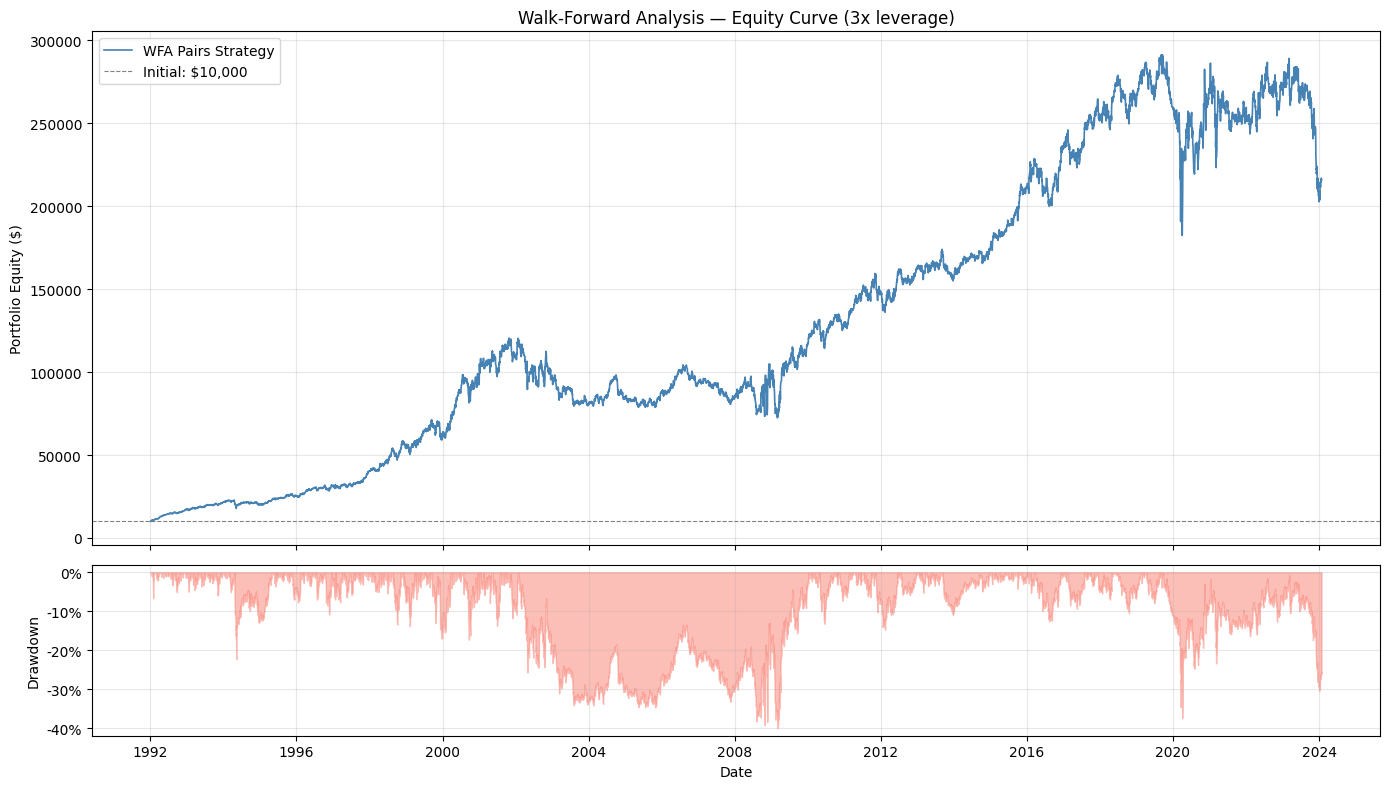


Performance summary:
  Cumulative      : 2057.02%
  Annualized      : 10.05%
  Sharpe           : 0.60
  Max drawdown     : -39.89%

Monthly return stats:
  Mean     : 0.91%
  Median   : 1.10%
  Worst    : -15.73%
  Best     : 17.95%
  % positive months: 61%


In [52]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from typing import cast

import pandas as pd

from pairs_eda import RollingPhase2Config, RollingPhase2Input, RollingPhase2Output

_wfa_result_obj = globals().get("wfa_result")
_wfa_input_obj = globals().get("wfa_input")
_wfa_config_obj = globals().get("wfa_config")
if _wfa_result_obj is None or _wfa_input_obj is None or _wfa_config_obj is None:
    raise RuntimeError("Run cell 74 first — wfa_result/wfa_input/wfa_config must be defined.")

wfa_result = cast(RollingPhase2Output, _wfa_result_obj)
wfa_input = cast(RollingPhase2Input, _wfa_input_obj)
wfa_config = cast(RollingPhase2Config, _wfa_config_obj)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1]})

# --- S&P 500 benchmark (buy & hold, same initial capital) ---
_eq_idx = cast(pd.DatetimeIndex, wfa_result.daily_equity.index)
_sp500_bench = sp500_daily_prices.mean(axis=1).loc[_eq_idx[0]:_eq_idx[-1]]
_sp500_bench = _sp500_bench / _sp500_bench.iloc[0] * wfa_input.initial_capital

# --- Equity curve ---
ax1 = axes[0]
ax1.plot(wfa_result.daily_equity.index, wfa_result.daily_equity.values,
         label="WFA Pairs Strategy", linewidth=1.2, color="steelblue")
ax1.plot(_sp500_bench.index, _sp500_bench.values,
         label="S&P 500 (equal-weight proxy)", linewidth=1.0, color="orange", alpha=0.7)
ax1.axhline(wfa_input.initial_capital, color="gray", linestyle="--",
            linewidth=0.8, label=f"Initial: ${wfa_input.initial_capital:,.0f}")
ax1.set_ylabel("Portfolio Equity ($)")
leverage_label = f" ({wfa_config.leverage:.0f}x leverage)" if wfa_config.leverage > 1.0 else ""
ax1.set_title(f"Walk-Forward Analysis — Equity Curve{leverage_label}")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)

# --- Drawdown ---
ax2 = axes[1]
running_max = wfa_result.daily_equity.cummax()
drawdown = wfa_result.daily_equity / running_max - 1.0
ax2.fill_between(drawdown.index, drawdown.values, 0, color="salmon", alpha=0.5)
ax2.set_ylabel("Drawdown")
ax2.set_xlabel("Date")
ax2.grid(True, alpha=0.3)
ax2.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.0%}"))

plt.tight_layout()
plt.show()

# --- Monthly returns summary ---
monthly = wfa_result.daily_return.resample("ME").apply(lambda x: (1 + x).prod() - 1)
_equity_index = cast(pd.DatetimeIndex, wfa_result.daily_equity.index)
_years_observed = max((_equity_index[-1] - _equity_index[0]).days / 365.25, 1.0)
annual_ret = (1 + wfa_result.summary["cumulative_return"]) ** (1 / _years_observed) - 1
print(f"\nPerformance summary:")
print(f"  Cumulative      : {wfa_result.summary['cumulative_return']:.2%}")
print(f"  Annualized      : {annual_ret:.2%}")
print(f"  Sharpe           : {wfa_result.summary['sharpe_ratio']:.2f}")
print(f"  Max drawdown     : {wfa_result.summary['max_drawdown']:.2%}")
print(f"\nMonthly return stats:")
print(f"  Mean     : {monthly.mean():.2%}")
print(f"  Median   : {monthly.median():.2%}")
print(f"  Worst    : {monthly.min():.2%}")
print(f"  Best     : {monthly.max():.2%}")
print(f"  % positive months: {(monthly > 0).mean():.0%}")

## Trade Analysis

Inspect individual trades — holding period, P&L distribution, exit reasons.

In [53]:
if not wfa_result.trades.empty:
    trades = wfa_result.trades.copy()
    print(f"Total trades: {len(trades)}")
    print(f"\nExit reasons:")
    print(trades["exit_reason"].value_counts().to_string())

    print(f"\nP&L distribution:")
    print(f"  Mean P&L per trade : ${trades['pnl'].mean():>8.2f}")
    print(f"  Median             : ${trades['pnl'].median():>8.2f}")
    print(f"  Win rate           : {(trades['pnl'] > 0).mean():.0%}")
    print(f"  Avg holding days   : {trades['holding_days'].mean():.1f}")

    print(f"\nTop 5 winners:")
    display(trades.nlargest(5, "pnl")[["pair_key", "entry_date", "exit_date", "pnl", "holding_days", "exit_reason"]])

    print(f"\nTop 5 losers:")
    display(trades.nsmallest(5, "pnl")[["pair_key", "entry_date", "exit_date", "pnl", "holding_days", "exit_reason"]])
else:
    print("No trades executed.")

Total trades: 5017

Exit reasons:
exit_reason
mean_reversion    4507
stop_loss          510

P&L distribution:
  Mean P&L per trade : $   46.84
  Median             : $  189.86
  Win rate           : 67%
  Avg holding days   : 15.2

Top 5 winners:


Loading ITables v2.7.1 from the internet... (need help?)



Top 5 losers:


Loading ITables v2.7.1 from the internet... (need help?)


## Rebalance History

How many pairs were scored and selected at each quarterly rebalance?
Shows the cointegration cache efficiency over time.

In [54]:
if not wfa_result.rebalance_table.empty:
    rebal = wfa_result.rebalance_table
    per_rebal = rebal.groupby("rebalance_date").agg(
        n_pairs=("pair_key", "nunique"),
        avg_score=("final_score", "mean"),
    ).reset_index()
    print(f"Rebalance windows: {len(per_rebal)}")
    display(per_rebal.head(10))
else:
    print("No rebalance data.")

print(f"\nCointegration cache performance:")
print(f"  Total tests run   : {wfa_result.summary.get('coint_tests_total', 0):.0f}")
print(f"  Total cache hits  : {wfa_result.summary.get('coint_cache_hits_total', 0):.0f}")
print(f"  Cache hit rate    : {wfa_result.summary.get('coint_cache_hit_rate', 0):.1%}")

Rebalance windows: 129


Loading ITables v2.7.1 from the internet... (need help?)



Cointegration cache performance:
  Total tests run   : 1217
  Total cache hits  : 22317
  Cache hit rate    : 94.8%
